In [26]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import os
import kagglehub


In [27]:
# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")
files = os.listdir(path)
data = pd.read_csv(os.path.join(path, 'spam.csv'), encoding='latin1')

## Cleaning dataset:

The dataset was first loaded from kagglehub: sms-spam-collection-dataset. To make it possible for the model to learn, we cleaned the dataset to retain only the relevant information:
- only the columns with sms message and 'spam/ham' labels were kept
- the 'spam' and 'ham' labels were turned into binary: 1 and 0 respectively, to make it compatible with ML algorithms
- missing rows were removed


In [28]:
print(data.shape)
print(data.head(3))
#print column names:
print(data.columns.tolist())

(5572, 5)
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


In [29]:
#clean dataset:
#keep only first two columns: v1 -> spam/ham and v2 -> text message
data = data[['v1', 'v2']].copy()
data.columns = ['label', 'message']
print(data.head(3))

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...


In [30]:
#check for missing data:
missing = data.isnull().sum()
print(missing)

label      0
message    0
dtype: int64


In [31]:
#removing rows with missing values
data = data.dropna().reset_index(drop=True) #reset index
print(data.shape)

(5572, 2)


In [32]:
print(data['label'].value_counts())
print(data.head())

#turning labels into binary:
data['label_num'] = data['label'].map({'ham':0, 'spam':1})
print(data['label_num'].value_counts())
data.sample(5)

label
ham     4825
spam     747
Name: count, dtype: int64
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
label_num
0    4825
1     747
Name: count, dtype: int64


,label,message,label_num
2020,ham,Anything lor but toa payoh got place 2 walk me...,0
3873,ham,No. Did you multimedia message them or e-mail?,0
152,ham,Ok... Ur typical reply...,0
1299,ham,Great to hear you are settling well. So what's...,0
1385,ham,That's ok. I popped in to ask bout something a...,0


C:\Users\sza90\AppData\Local\Temp\ipykernel_13264\3253969108.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=data, palette='Set2')


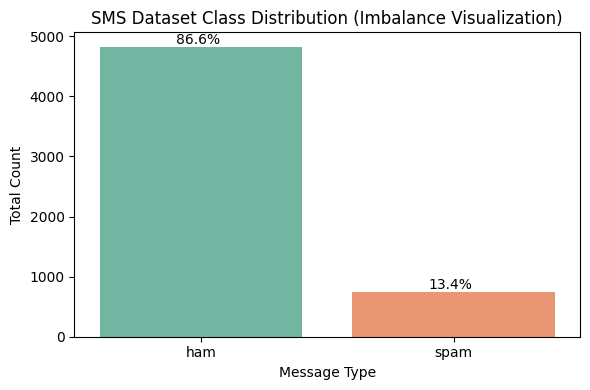

In [33]:
# Fulfills Presentation & Visualization Criteria (4b)
import seaborn as sns
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='label', data=data, palette='Set2')
plt.title('SMS Dataset Class Distribution (Imbalance Visualization)', fontsize=12)
plt.xlabel('Message Type')
plt.ylabel('Total Count')

# Add percentage annotations on top of the bars
total = len(data)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2.0 - 0.1, p.get_height() + 50))

plt.tight_layout()
plt.show()

Tokenizing

Text preprocessing was applied to normalize the SMS messages and reduce noise.
- all messages were converted to lowercase and tokenized into individual words
- removed unnecessary punctuation and stopwords
- lemmatized to reduce words to their base forms
- his process helps improve model performance by reducing vocabulary complexity and emphasizing meaningful textual patterns.

In [34]:
import string, re, nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [35]:
#nltk.downnload('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sza90\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sza90\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sza90\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [36]:
#preprocessing text:
#tools:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

#turning into function
def clean_text(text):
    """
    Normalizes and cleans raw text messages by converting to lowercase, 
    removing punctuation/special characters, eliminating stop words, 
    and lemmatizing words to their root forms.

    Parameters:
    -----------
    text : str
        The raw SMS text string to be processed.

    Returns:
    --------
    str
        A cleaned, space-separated string of lemmatized text tokens.
    """
    # Convert text to lowercase
    text = text.lower()
    
    # Remove special characters and punctuation
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    
    # Split text into words
    words = text.split()
    
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # Lemmatize words
    words = [lemmatizer.lemmatize(word) for word in words]
    
    # Join words back into one sentence
    cleaned_text = ' '.join(words)
    
    return cleaned_text

data['clean_message'] = data['message'].apply(clean_text)

print(data[['message', 'clean_message']].head())

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                       clean_message  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry 2 wkly comp win fa cup final tkts 2...  
3                u dun say early hor u c already say  
4           nah dont think go usf life around though  


In [37]:
print(data.sample(5))


     label                                            message  label_num  \
4980   ham                             I said its okay. Sorry          0   
3654   ham                    Senthil group company Apnt 5pm.          0   
3043   ham  Let me know how it changes in the next 6hrs. I...          0   
906   spam  all the lastest from Stereophonics, Marley, Di...          1   
1690  spam  Sunshine Quiz Wkly Q! Win a top Sony DVD playe...          1   

                                          clean_message  
4980                                    said okay sorry  
3654                     senthil group company apnt 5pm  
3043  let know change next 6hrs even appendix age ra...  
906   lastest stereophonics marley dizzee racal libe...  
1690  sunshine quiz wkly q win top sony dvd player u...  


In [38]:
#ml libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns


## Dataset Splitting & Vectorization (Feature Extraction)
We isolate independent data features from target vectors, split the dataset using stratified distribution to preserve structural representation, and vectorize text using **TF-IDF weights** (Term Frequency-Inverse Document Frequency) limited to the top 5,000 components.
## Fitting model:

In [39]:
X = data['clean_message']
y = data['label_num']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape

((4457,), (1115,))

In [40]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vector = vectorizer.fit_transform(X_train)
X_test_vector = vectorizer.transform(X_test)

X_train_vector.shape, X_test_vector.shape

((4457, 5000), (1115, 5000))

In [41]:
svm_model = SVC(kernel='linear', C=2, random_state=42)

svm_model.fit(X_train_vector,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",2
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [42]:
y_pred = svm_model.predict(X_test_vector)

y_pred[:10]

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0])

## Precision and interpretation of model:

### Empirical Evaluation Metrics
Below we analyze the classification metrics. Because text data classes are highly imbalanced, we pay special attention to the **Precision** and **Recall** values of the `Spam (1)` group rather than simple holistic **Accuracy**.

In [43]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9847533632286996
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.98      0.98      0.98      1115



In [44]:
# investigating typical words
feature_names = vectorizer.get_feature_names_out()
coefficients = svm_model.coef_.toarray()[0]

top_spam_words = [feature_names[i] for i in coefficients.argsort()[-20:]]
top_ham_words = [feature_names[i] for i in coefficients.argsort()[:20]]

print("Top spam words:", top_spam_words)
print("Top ham words:", top_ham_words)

Top spam words: ['voicemail', 'urgent', '18', 'credit', 'freeringtonereply', 'reply', 'uk', '250', 'stop', 'information', '500', 'ac', 'prize', 'mobile', 'ringtone', '22', '88066', 'claim', 'txt', 'service']
Top ham words: ['liked', 'ltgt', 'sir', 'hey', 'yup', 'doesnt', 'mail', 'dhoni', 'ill', 'jade', 'gonna', 'machan', 'bak', 'pa', 'morning', 'im', 'later', 'alright', 'happy', 'sorry']


In [45]:
#cross validation:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    svm_model,
    X_train_vector,
    y_train,
    cv=5
)

print(scores)
print("Average accuracy:", scores.mean())


[0.98206278 0.98318386 0.98316498 0.97867565 0.97979798]
Average accuracy: 0.9813770490153152


In [46]:
cm = confusion_matrix(y_test, y_pred)

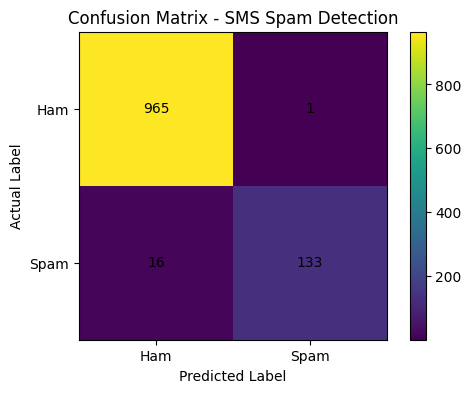

In [47]:
plt.figure(figsize=(6, 4))

plt.imshow(cm)
plt.title("Confusion Matrix - SMS Spam Detection")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ['Ham', 'Spam'])
plt.yticks([0, 1], ['Ham', 'Spam'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

In [48]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Message': X_test.values
})

results['Actual'] = results['Actual'].map({0: 'Ham', 1: 'Spam'})
results['Predicted'] = results['Predicted'].map({0: 'Ham', 1: 'Spam'})

results.head(10)

,Actual,Predicted,Message
0,Ham,Ham,oh right ok ill make sure load work day got re...
1,Ham,Ham,tirupur call da
2,Ham,Ham,mean fat head
3,Spam,Spam,1000 cash 2000 prize claim call09050000327
4,Ham,Ham,come aftr ltdecimalgt cleaning house
5,Ham,Ham,friendship poem dear dear u r near hear dont g...
6,Ham,Ham,wot wed nite 3 til 9
7,Ham,Ham,dont talk ever ok word
8,Ham,Ham,congrats kanowhr treat maga
9,Ham,Ham,eh u remember 2 spell name yes v naughty make ...


In [49]:
import pickle
# Save optimized assets to disk as demonstrated in your original script
with open('svm_spam_model.pkl', 'wb') as file:
    pickle.dump(svm_model, file)

with open('tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(vectorizer, file)

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.


In [50]:
with open('svm_spam_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

with open('tfidf_vectorizer.pkl', 'rb') as file:
    loaded_vectorizer = pickle.load(file)

In [51]:
def predict_sms_loaded(message):
    """
    Takes a raw string message, cleans it, applies the vectorizer transformations,
    and conducts model inference using the trained configuration.

    Parameters:
    -----------
    message : str
        The raw, unprocessed text string to test.

    Returns:
    --------
    str
        "Spam" if malicious keywords/patterns are found; otherwise "Ham".
    """
    cleaned_message = clean_text(message)
    message_vectorized = loaded_vectorizer.transform([cleaned_message])
    prediction = loaded_model.predict(message_vectorized)
    
    if prediction[0] == 1:
        return "Spam"
    else:
        return "Ham"

In [52]:
new_message = "Win a brand new car today. Call this number now!"

print(new_message, "->", predict_sms_loaded(new_message))

Win a brand new car today. Call this number now! -> Ham


## Advanced Extensions & Model Comparison
This section introduces an optimized approach to handle dataset class imbalance, performs hyperparameter tuning, and benchmarks the Support Vector Machine against an alternative Bayesian model from the course syllabus.

Hyperparameter Optimization (SVM tuning)

In [53]:
from sklearn.model_selection import GridSearchCV

# 1. Define hyperparameter combination grid
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'class_weight': ['balanced', None] # Addresses class imbalance scientifically
}

# 2. Setup grid search cross-validation targeting the F1-Score
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_vector, y_train)

# 3. Extract the optimized model
optimized_svm_model = grid_search.best_estimator_
print("Optimized SVM Hyperparameters Found:", grid_search.best_params_)

# 4. Predict using the tuned model configuration
svm_opt_preds = optimized_svm_model.predict(X_test_vector)

Optimized SVM Hyperparameters Found: {'C': 10, 'class_weight': None, 'kernel': 'linear'}


Comparative Baseline (Naive Bayes)

In [54]:
from sklearn.naive_bayes import MultinomialNB

# Implement a Multinomial Naive Bayes model as an alternative text classifier benchmark
nb_model = MultinomialNB()
nb_model.fit(X_train_vector, y_train)

# Generate predictions
nb_preds = nb_model.predict(X_test_vector)

Visual Evaluation Metrics

=== Optimized SVM Performance Report ===
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.97      0.90      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115


=== Bayesian Naive Bayes Performance Report ===
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.99      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



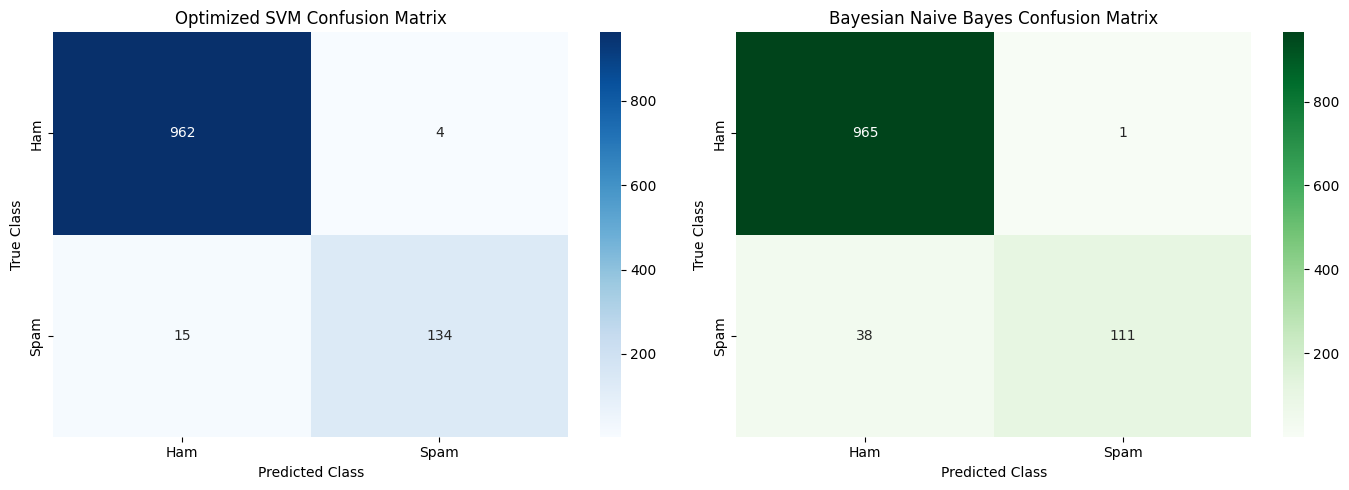

In [55]:
# 1. Generate full precision, recall, and f1-score comparison matrices
print("=== Optimized SVM Performance Report ===")
print(classification_report(y_test, svm_opt_preds, target_names=['Ham', 'Spam']))

print("\n=== Bayesian Naive Bayes Performance Report ===")
print(classification_report(y_test, nb_preds, target_names=['Ham', 'Spam']))

# 2. Plot Side-by-Side Confusion Matrix Heatmaps (Fulfills presentation criteria)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, svm_opt_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[0].set_title('Optimized SVM Confusion Matrix')
axes[0].set_xlabel('Predicted Class')
axes[0].set_ylabel('True Class')

sns.heatmap(confusion_matrix(y_test, nb_preds), annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[1].set_title('Bayesian Naive Bayes Confusion Matrix')
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('True Class')

plt.tight_layout()
plt.show()